## Figure S1

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)

## t2m

In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)


#define na_mask as  all of 1.NA SPSS, 2.NA STSS, 3.NA STPS
#after Fay and McKinley 2014
#see https://github.com/RECCAP2-ocean/R2-shared-resources/blob/master/data/regions/README.md

npol_land = (masks.seamask == 0).where(masks.lat >=60)
nmidlat_land = (masks.seamask == 0).where((masks.lat <60) & (masks.lat >=20))
trop_land = (masks.seamask == 0).where((masks.lat <20) & (masks.lat >=-20))
smidlat_land = (masks.seamask == 0).where((masks.lat < -20) & (masks.lat >=-60))
spol_land = (masks.seamask == 0).where(masks.lat <-60)

land_mask = masks.seamask == 0

In [4]:
fp = '/data/jmex/ERA5/monthly/recent/era5_t2m.nc'
t2m = xr.open_dataset(fp).sel(valid_time = slice('1979', None))

#change variable names
t2m = t2m.rename({'latitude':'lat', 'longitude':'lon'})
t2m = t2m.drop_vars(['number', 'expver'])


t2m = t2m.rename({'valid_time':'time'})
t2m['time'] = pd.to_datetime(t2m['time'].values.astype(str), format='%Y-%m-%d')


In [5]:
t2m = t2m.where(land_mask)

In [6]:
weights = np.cos(np.deg2rad(land_mask.lat))


land_surface = land_mask.weighted(weights).sum()

In [7]:
#make sure all add up to one: 
npol_land.weighted(weights).sum()/land_surface + \
nmidlat_land.weighted(weights).sum()/land_surface + \
trop_land.weighted(weights).sum()/land_surface + \
smidlat_land.weighted(weights).sum()/land_surface + \
spol_land.weighted(weights).sum()/land_surface

<xarray.DataArray 'seamask' ()>
array(1.)

In [8]:
#take aso season only
t2m = t2m.where(t2m.time.dt.month.isin([8,9,10])).groupby('time.year').mean()


In [9]:
clim = t2m.sel(year = slice('1991', '2020')).mean('year')
t2m['anom'] = t2m.t2m - clim.t2m

In [10]:
#compute all regional contributions
npol = t2m.where(npol_land).weighted(weights).mean(['lat', 'lon'])
npol = npol * npol_land.weighted(weights).sum()/land_surface

nmidlat = t2m.where(nmidlat_land).weighted(weights).mean(['lat', 'lon'])
nmidlat = nmidlat * nmidlat_land.weighted(weights).sum()/land_surface

trop = t2m.where(trop_land).weighted(weights).mean(['lat', 'lon'])
trop = trop * trop_land.weighted(weights).sum()/land_surface

smidlat = t2m.where(smidlat_land).weighted(weights).mean(['lat', 'lon'])
smidlat = smidlat * smidlat_land.weighted(weights).sum()/land_surface

spol = t2m.where(spol_land).weighted(weights).mean(['lat', 'lon'])
spol = spol * spol_land.weighted(weights).sum()/land_surface


In [11]:
ls = [npol, nmidlat, trop, smidlat, spol][::-1]

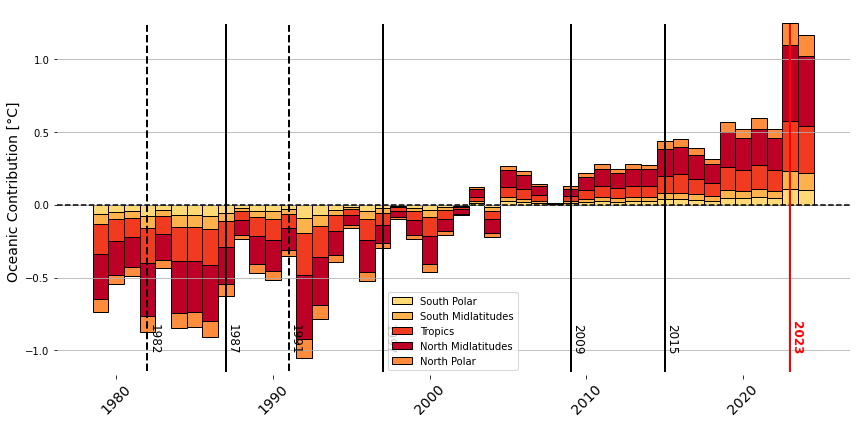

In [14]:
# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))


labels = ['North Polar', 'North Midlatitudes', 'Tropics', 'South Midlatitudes', 'South Polar'][::-1]

colors = ['#fd8d3c',  '#bd0026', '#f03b20', '#feb24c', '#fed976'][::-1]



bottom_pos = np.zeros(len(npol['year']))
bottom_neg = np.zeros(len(npol['year']))

for i, r in enumerate(ls):
    values = r['anom'].values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Oceanic Contribution [°C]', fontsize = 14, fontweight = 'normal')

# Define the years of interest and their positions on the x-axis
years_of_interest = [1982, 1987, 1991, 1997, 2009, 2015, 2023]

for year in years_of_interest:
    if year == 2023:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12, fontweight = 'bold', color = 'r')
    else:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12)
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    if year in [1982, 1991]:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='--', color='k', linewidth=2)
    elif year == 2023:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='r', linewidth=2)
    else:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='k', linewidth=2)
    



'''
ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('ONI', color='k', fontsize = 12)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor='k')
ax2.plot(oni.year,oni.oni9, marker = 'o', c = 'k', linestyle = '--')
#ax.legend()    

ax.set_ylim(-0.5,0.7)
ax2.set_ylim(-5/12 * 6,7/12 *6)
'''
for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()

fig.savefig('output/FigS1a_final.svg', bbox_inches='tight')


#ax.legend()

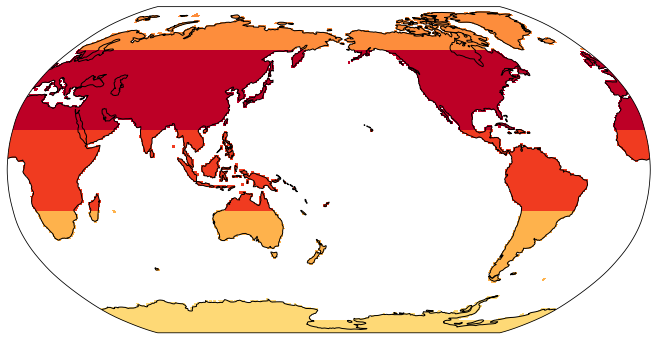

In [21]:
#make a plot in robinson projection of all the regional masks using the corect coloring
#plotting for the ind_mask, tropical_pacific_mask, extratropical_pacific_mask, southern_mask, sa_mask, na_mask, npol_mask


import cartopy.crs as ccrs

projection = ccrs.Robinson(central_longitude=180)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=projection)

masks_to_plot = {
    'South Polar': spol_land,
    'South Midlatitudes': smidlat_land,
    'Tropics': trop_land,
    'North Midlatitudes': nmidlat_land,
    'North Polar': npol_land
    
}

for (region, mask), color in zip(masks_to_plot.items(), colors):
    masked_data = mask.where(mask, other=np.nan)
    masked_data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                               cmap=mcolors.ListedColormap([color]),
                               add_colorbar=False,
                               alpha=1)


ax.coastlines()


fig.savefig('output/FigS1a2_final.png', dpi = 600, bbox_inches='tight')


## Bar Code

In [16]:
fp = '/data/jmex/ERA5/monthly/recent/era5_t2m.nc'
t2m = xr.open_dataset(fp).sel(valid_time = slice('1979', '2024'))

#change variable names
t2m = t2m.rename({'latitude':'lat', 'longitude':'lon'})
t2m = t2m.drop_vars(['number', 'expver'])


t2m = t2m.rename({'valid_time':'time'})
t2m['time'] = pd.to_datetime(t2m['time'].values.astype(str), format='%Y-%m-%d')




In [17]:
#aso only
t2m = t2m.where(t2m.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [18]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)

In [19]:
#mask to have ocean only
t2m = t2m.where(masks.seamask ==0)


#compute mean
weights = np.cos(np.deg2rad(masks.lat))
t = t2m.weighted(weights).mean(['lat', 'lon'])
dt = t - t.shift(year = 1)


## All Land

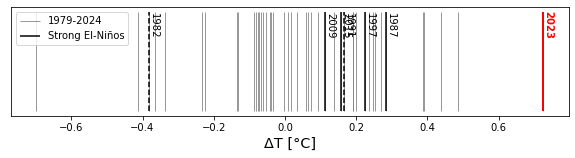

In [20]:
# Assuming dt.t2m and dt.year exist


composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dt_composite = dt.where(dt.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dt.t2m, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dt.sel(year = 1982).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1987).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 1991).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1997).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2009).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2015).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dt_composite.year.values: 
    x = dt.sel(year = y).t2m
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dt.sel(year= 2023).t2m
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔT [°C]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dt.t2m")

plt.legend(loc = 'upper left')
#fig.savefig('Figures/Fig1a.png', dpi = 600, format = 'png', bbox_inches='tight')

fig.savefig('output/FigS1b_final.svg', bbox_inches='tight')
